In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

for _fp in fm.findSystemFonts(fontext='ttf'):
    if 'malgun' in _fp.lower() or 'nanum' in _fp.lower():
        plt.rcParams['font.family'] = fm.FontProperties(fname=_fp).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

panel = pd.read_csv('data/monthly_panel_ml.csv', parse_dates=['date']).set_index('date')
panel = panel.sort_index()

print(f'패널: {panel.shape}')
print(f'기간: {panel.index.min().date()} ~ {panel.index.max().date()}')
print(f'종목: {panel["ticker"].nunique()}개')
print(f'\n컬럼 ({len(panel.columns)}개):')
print(list(panel.columns))

패널: (108180, 69)
기간: 2004-01-31 ~ 2025-12-31
종목: 621개

컬럼 (69개):
['ticker', 'mom_1w', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m', 'mom_12m_skip_1m', 'chmom', 'vol_21d', 'vol_60d', 'vol_252d', 'beta_252d', 'idiovol_21d', 'ivol_63d', 'log_mcap', 'vol_surge', 'dollar_vol_21d', 'amihud_21d', 'high52w_ratio', 'low52w_ratio', 'maxret_21d', 'ma_gap_20_60', 'rsi_14', 'bb_pct', 'intraday_range', 'autocorr_21d', 'sharpe_21d', 'sharpe_63d', 'sortino_63d', 'ir_63d', 'skew_63d', 'kurt_63d', 'mdd_252d', 'indmom', 'fwd_ret_1m', 'gics_sector', 'ret_1m', 'rf_1m', 'fwd_excess_ret_1m', 'spy_ret', 'is_Energy', 'is_Materials', 'is_Industrials', 'is_Consumer_Discretionary', 'is_Consumer_Staples', 'is_Health_Care', 'is_Financials', 'is_Information_Technology', 'is_Communication_Services', 'is_Utilities', 'is_Real_Estate', 'vix', 'dxy', 'gold', 'wti_crude', 'copper', 'silver', 'skew_idx', 't10y2y', 'icsa', 'sahm', 'cpi', 'unrate', 'ff_mkt_rf', 'ff_smb', 'ff_hml', 'ff_rmw', 'ff_cma', 'ff_mom_factor']


# 1. 타겟 변수 분포 — fwd_excess_ret_1m

DIR_THR를 얼마로 설정할지 결정하는 핵심 셀입니다.

=== fwd_excess_ret_1m 기초통계 ===
count    108177.0000
mean          0.0100
std           0.0929
min          -0.8448
5%           -0.1289
10%          -0.0895
25%          -0.0378
50%           0.0108
75%           0.0573
90%           0.1070
95%           0.1465
max           2.4497
Name: fwd_excess_ret_1m, dtype: float64

=== DIR_THR별 클래스 비율 ===
   DIR_THR      down   neutral        up
     0.000     43.8%      0.0%     56.2%
     0.003     42.0%      3.4%     54.5%
     0.005     40.9%      5.7%     53.4%
     0.008     39.2%      9.2%     51.6%
     0.010     38.1%     11.5%     50.5%
     0.015     35.5%     17.0%     47.5%
     0.020     33.0%     22.4%     44.6%
     0.050     20.3%     51.4%     28.3%


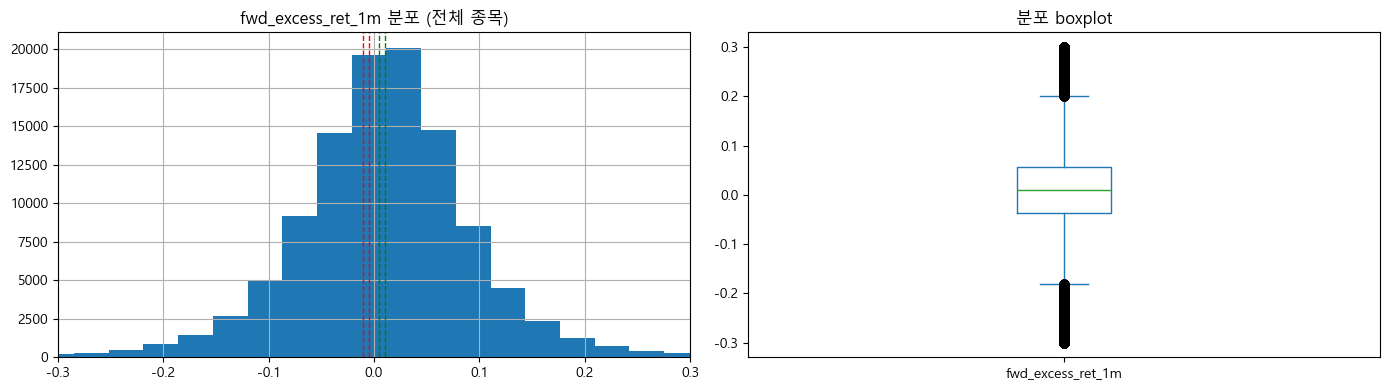

In [2]:
ret = panel['fwd_excess_ret_1m'].dropna()

print('=== fwd_excess_ret_1m 기초통계 ===')
print(ret.describe(percentiles=[.05,.1,.25,.5,.75,.9,.95]).round(4))

# 다양한 DIR_THR 후보별 클래스 비율
print('\n=== DIR_THR별 클래스 비율 ===')
print(f'{"DIR_THR":>10}  {"down":>8}  {"neutral":>8}  {"up":>8}')
for thr in [0.0, 0.003, 0.005, 0.008, 0.010, 0.015, 0.020,0.05]:
    up  = (ret >  thr).mean()
    dn  = (ret < -thr).mean()
    neu = 1 - up - dn
    print(f'{thr:>10.3f}  {dn:>8.1%}  {neu:>8.1%}  {up:>8.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ret.hist(bins=100, ax=axes[0])
for thr in [0.005, 0.01]:
    axes[0].axvline( thr, color='green', ls='--', lw=1)
    axes[0].axvline(-thr, color='red',   ls='--', lw=1)
axes[0].set_title('fwd_excess_ret_1m 분포 (전체 종목)')
axes[0].set_xlim(-0.3, 0.3)

ret.clip(-0.3, 0.3).plot(kind='box', ax=axes[1])
axes[1].set_title('분포 boxplot')

plt.tight_layout()
plt.show()

In [3]:
panel[panel['fwd_excess_ret_1m'] > 2]

,ticker,mom_1w,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_skip_1m,chmom,vol_21d,vol_60d,...,icsa,sahm,cpi,unrate,ff_mkt_rf,ff_smb,ff_hml,ff_rmw,ff_cma,ff_mom_factor
date,,,,,,,,,,,,,,,,,,,,,
2008-12-31,GR,-0.500000,-0.666667,-0.888889,-0.954545,-0.970588,-0.911765,-0.601604,3.691817,3.545075,...,533000.0,2.07,211.398,7.3,0.0177,0.0333,0.0005,0.0003,-0.0152,-0.0509
2009-07-31,AIG,0.054575,-0.273230,-0.523913,-0.486719,-0.974524,-0.964946,0.463648,1.796754,1.362742,...,587000.0,3.80,214.726,9.5,0.0774,0.0231,0.0489,-0.0026,0.0308,-0.0554
2010-01-31,GR,0.058823,-0.100000,-0.181818,-0.437500,1.250000,1.500000,-3.437500,1.338146,1.906836,...,496000.0,2.57,217.488,9.8,-0.0335,0.0040,0.0033,-0.0108,0.0051,-0.0533
2020-03-31,APA,-0.250896,-0.836207,-0.834814,-0.833606,-0.876042,-0.243204,-0.578572,3.384109,2.154615,...,5946000.0,0.30,258.076,4.4,-0.1335,-0.0818,-0.1383,-0.0161,0.0119,0.0821


# 2. 종목별 분류 정확도 직접 확인

포트폴리오 집계 없이, 개별 종목 레벨에서 방향 예측이 되는지 확인합니다.

방법: 간단한 expanding window로 각 월에 대해 직전 1년 데이터로 학습 → 당월 예측 → 실제와 비교

In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import balanced_accuracy_score

# 횡단면 분위수 기반 3분류: 하위 30%=down, 중간 40%=neutral, 상위 30%=up
PCT = 0.30

def cs_label(group):
    r = group['fwd_excess_ret_1m']
    lo = r.quantile(PCT)
    hi = r.quantile(1 - PCT)
    label = pd.Series(1, index=group.index)  # default = neutral
    label[r <= lo] = 0  # down
    label[r >= hi] = 2  # up
    return label

panel['label'] = panel.groupby(panel.index, group_keys=False).apply(cs_label)
print(f'레이블 분포: {panel["label"].value_counts().sort_index().to_dict()}')

FEATS = [
    'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m',
    'vol_21d', 'vol_60d', 'beta_252d', 'idiovol_21d',
    'log_mcap', 'rsi_14', 'ma_gap_20_60',
    'sharpe_21d', 'sharpe_63d', 'mdd_252d',
    'high52w_ratio', 'autocorr_21d',
]
FEATS = [f for f in FEATS if f in panel.columns]

all_years = sorted(panel.index.year.unique())
pred_years = [y for y in all_years if y >= 2009]

results = []
for test_year in pred_years:
    train = panel[panel.index.year < test_year].dropna(subset=['label'] + FEATS[:3])
    test  = panel[panel.index.year == test_year].dropna(subset=['label'] + FEATS[:3])
    if len(train) < 1000 or len(test) < 50:
        continue

    X_tr = train[FEATS].fillna(0)
    y_tr = train['label'].astype(int)
    X_te = test[FEATS].fillna(0)
    y_te = test['label'].astype(int)

    if y_tr.nunique() < 2:
        continue

    clf = XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.6,
        objective='multi:softprob', num_class=3,
        random_state=42, verbosity=0,
    )
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    ba  = balanced_accuracy_score(y_te, y_pred)
    acc = (y_te == y_pred).mean()

    mask_bin = (y_te != 1) & (y_pred != 1)
    ba_bin = balanced_accuracy_score(y_te[mask_bin], y_pred[mask_bin]) if mask_bin.sum() > 10 else np.nan

    results.append({'year': test_year, 'BA_3class': ba, 'Acc': acc,
                    'BA_binary': ba_bin, 'n_test': len(y_te)})
    print(f'  {test_year}: BA={ba:.3f}  Acc={acc:.3f}  BA(up/down)={ba_bin:.3f}  N={len(y_te)}')

res_df = pd.DataFrame(results).set_index('year')
print(f'\n=== 평균 성능 (횡단면 상하위 {PCT*100:.0f}%) ===')
print(res_df.mean().round(3))

레이블 분포: {0: 32518, 1: 43144, 2: 32518}
  2009: BA=0.373  Acc=0.387  BA(up/down)=0.489  N=4272
  2010: BA=0.369  Acc=0.404  BA(up/down)=0.527  N=4297
  2011: BA=0.367  Acc=0.413  BA(up/down)=0.549  N=4359
  2012: BA=0.371  Acc=0.422  BA(up/down)=0.520  N=4488
  2013: BA=0.365  Acc=0.421  BA(up/down)=0.518  N=4652
  2014: BA=0.352  Acc=0.410  BA(up/down)=0.522  N=4750
  2015: BA=0.363  Acc=0.420  BA(up/down)=0.544  N=4875
  2016: BA=0.368  Acc=0.419  BA(up/down)=0.539  N=5135
  2017: BA=0.362  Acc=0.415  BA(up/down)=0.507  N=5300
  2018: BA=0.360  Acc=0.413  BA(up/down)=0.547  N=5371
  2019: BA=0.367  Acc=0.420  BA(up/down)=0.563  N=5411
  2020: BA=0.346  Acc=0.385  BA(up/down)=0.447  N=5559
  2021: BA=0.368  Acc=0.414  BA(up/down)=0.514  N=5653
  2022: BA=0.376  Acc=0.420  BA(up/down)=0.553  N=5746
  2023: BA=0.359  Acc=0.413  BA(up/down)=0.491  N=5847
  2024: BA=0.373  Acc=0.425  BA(up/down)=0.508  N=5883
  2025: BA=0.371  Acc=0.418  BA(up/down)=0.512  N=5958

=== 평균 성능 (횡단면 상하위 30%) =

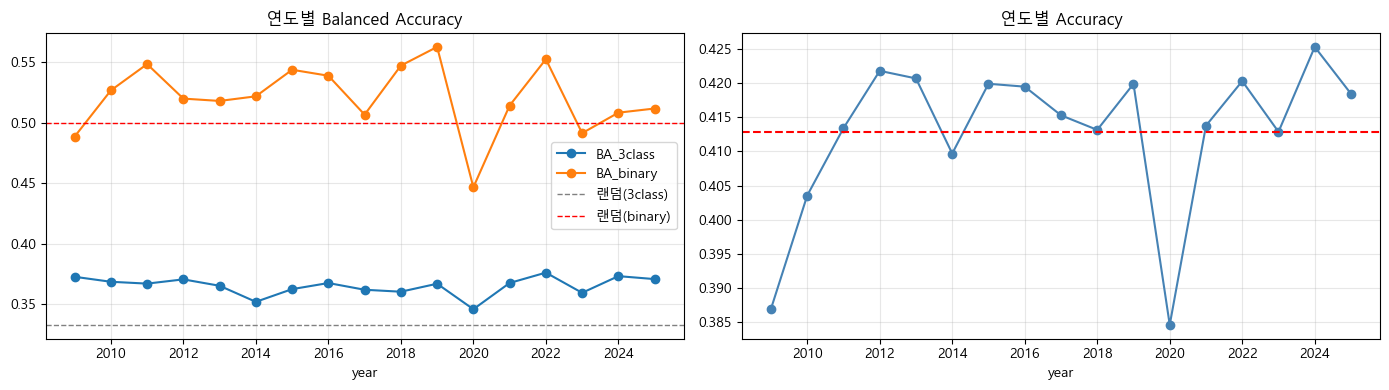

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

res_df[['BA_3class', 'BA_binary']].plot(ax=axes[0], marker='o')
axes[0].axhline(0.333, color='gray', ls='--', lw=1, label='랜덤(3class)')
axes[0].axhline(0.5,   color='red',  ls='--', lw=1, label='랜덤(binary)')
axes[0].set_title('연도별 Balanced Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

res_df['Acc'].plot(ax=axes[1], marker='o', color='steelblue')
axes[1].axhline(res_df['Acc'].mean(), color='red', ls='--')
axes[1].set_title('연도별 Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2-1. 혼동 행렬 상세 — 부호 반전 오류 분석

실제 방향과 예측 방향이 **반대 부호**인 경우가 얼마나 되는지 확인합니다.
- actual=up(2), pred=down(0): 올라가는 종목을 내린다고 예측 → Q 부호 반전
- actual=down(0), pred=up(2): 내려가는 종목을 올린다고 예측 → Q 부호 반전
- actual=neutral(1), pred=down(0) or up(2): 중립을 방향성 있다고 예측

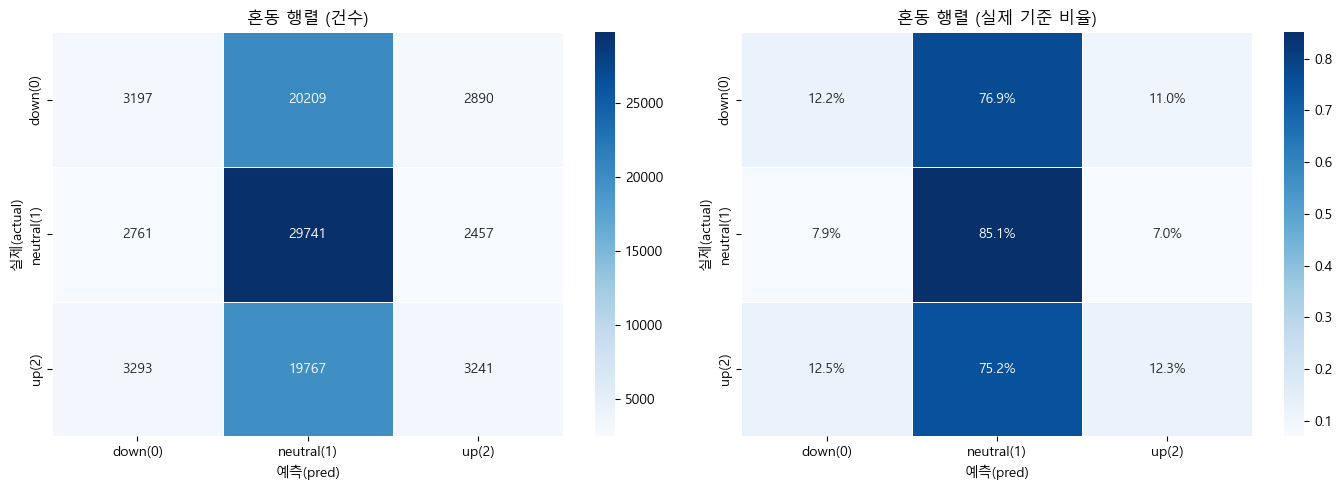

=== 부호 반전 오류 ===
actual=up(2)   → pred=down(0):   3293 /  26301 = 12.5%
actual=down(0) → pred=up(2):     2890 /  26296 = 11.0%
actual=neu(1)  → pred=down(0):   2761 /  34959 = 7.9%
actual=neu(1)  → pred=up(2):     2457 /  34959 = 7.0%

부호 완전 반전: 6183 / 87556 = 7.1%
랜덤 기대값:    ~18.0%

=== 방향 예측 시만 (20.4%) ===
  정확히 맞힘: 36.1%
  부호 반전:   34.7%  (랜덤: 25.0%)


In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_actual, all_pred = [], []

for test_year in pred_years:
    train = panel[panel.index.year < test_year].dropna(subset=['label'] + FEATS[:3])
    test  = panel[panel.index.year == test_year].dropna(subset=['label'] + FEATS[:3])
    if len(train) < 1000 or len(test) < 50:
        continue
    X_tr = train[FEATS].fillna(0)
    y_tr = train['label'].astype(int)
    X_te = test[FEATS].fillna(0)
    y_te = test['label'].astype(int)
    if y_tr.nunique() < 2:
        continue
    clf = XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.6,
        objective='multi:softprob', num_class=3,
        random_state=42, verbosity=0,
    )
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    all_actual.extend(y_te.tolist())
    all_pred.extend(y_pred.tolist())

actual_arr = np.array(all_actual)
pred_arr   = np.array(all_pred)

# ── 혼동 행렬
cm = confusion_matrix(actual_arr, pred_arr, labels=[0, 1, 2])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
label_names = ['down(0)', 'neutral(1)', 'up(2)']
for ax, mat, title, fmt in zip(axes,
                                [cm, cm_norm],
                                ['혼동 행렬 (건수)', '혼동 행렬 (실제 기준 비율)'],
                                ['.0f', '.1%']):
    sns.heatmap(mat, annot=True, fmt=fmt,
                xticklabels=label_names, yticklabels=label_names,
                cmap='Blues', ax=ax, linewidths=0.5)
    ax.set_xlabel('예측(pred)')
    ax.set_ylabel('실제(actual)')
    ax.set_title(title)
plt.tight_layout()
plt.savefig('outputs/05_ml_q/eda_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

total  = len(actual_arr)
n_up   = (actual_arr == 2).sum()
n_down = (actual_arr == 0).sum()
n_neu  = (actual_arr == 1).sum()
up_as_down  = ((actual_arr == 2) & (pred_arr == 0)).sum()
down_as_up  = ((actual_arr == 0) & (pred_arr == 2)).sum()
neu_as_down = ((actual_arr == 1) & (pred_arr == 0)).sum()
neu_as_up   = ((actual_arr == 1) & (pred_arr == 2)).sum()

print('=== 부호 반전 오류 ===')
print(f'actual=up(2)   → pred=down(0): {up_as_down:6d} / {n_up:6d} = {up_as_down/n_up:.1%}')
print(f'actual=down(0) → pred=up(2):   {down_as_up:6d} / {n_down:6d} = {down_as_up/n_down:.1%}')
print(f'actual=neu(1)  → pred=down(0): {neu_as_down:6d} / {n_neu:6d} = {neu_as_down/n_neu:.1%}')
print(f'actual=neu(1)  → pred=up(2):   {neu_as_up:6d} / {n_neu:6d} = {neu_as_up/n_neu:.1%}')

total_flip = up_as_down + down_as_up
print(f'\n부호 완전 반전: {total_flip} / {total} = {total_flip/total:.1%}')
print(f'랜덤 기대값:    ~{n_up/total * n_down/total * 2:.1%}')

# 방향 예측 시 신뢰도
dir_mask = pred_arr != 1
n_dir    = dir_mask.sum()
pred_d   = pred_arr[dir_mask]
actual_d = actual_arr[dir_mask]
sign_flip_d = (((actual_d == 2) & (pred_d == 0)) | ((actual_d == 0) & (pred_d == 2))).sum()
correct_d   = (pred_d == actual_d).sum()

print(f'\n=== 방향 예측 시만 ({n_dir/total:.1%}) ===')
print(f'  정확히 맞힘: {correct_d/n_dir:.1%}')
print(f'  부호 반전:   {sign_flip_d/n_dir:.1%}  (랜덤: {(actual_d==2).mean()*(actual_d==0).mean()*2:.1%})')

# 3. P_ret 분포 (포트폴리오 레벨)

P 포트폴리오 실현 수익률 분포 확인

=== P_ret 기초통계 ===
count    263.0000
mean       0.0034
std        0.0604
min       -0.2411
10%       -0.0626
25%       -0.0307
50%        0.0033
75%        0.0358
90%        0.0671
max        0.2787
Name: p_ret, dtype: float64

=== DIR_THR별 up/neutral/down 비율 (포트폴리오 레벨) ===
   DIR_THR      down   neutral        up
     0.000     47.1%      0.0%     52.9%
     0.003     44.9%      4.6%     50.6%
     0.005     44.1%      8.4%     47.5%
     0.008     41.4%     14.8%     43.7%
     0.010     39.5%     18.3%     42.2%
     0.020     31.9%     31.9%     36.1%
     0.050     13.7%     68.8%     17.5%


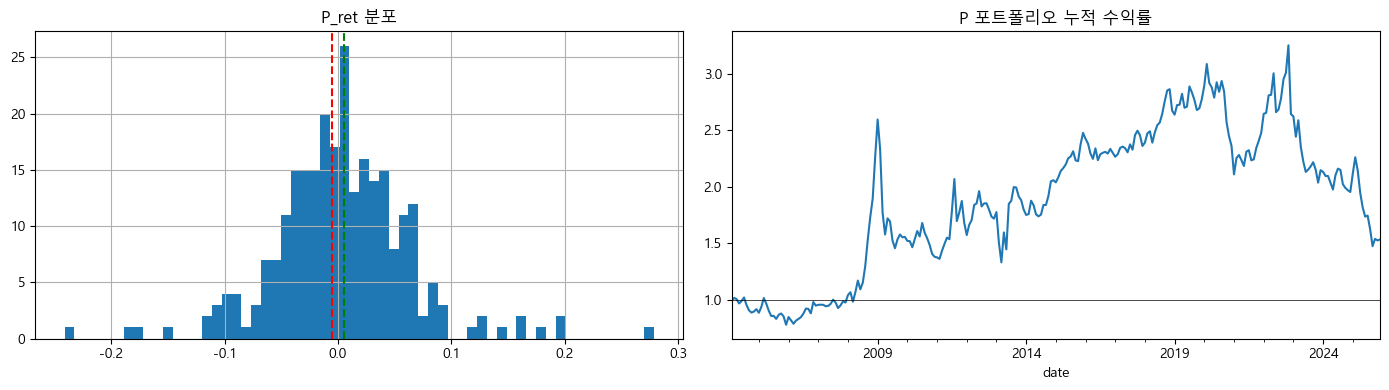

In [7]:
PCT_GROUP = 0.30

p_records = []
for date, grp in panel.groupby(panel.index):
    g = grp.dropna(subset=['vol_21d', 'log_mcap', 'fwd_excess_ret_1m']).reset_index(drop=True)
    if len(g) < 30:
        continue
    n_g = max(1, int(len(g) * PCT_GROUP))
    sv  = g['vol_21d'].sort_values()
    lo, hi = sv.index[:n_g], sv.index[-n_g:]
    cap_lo = np.exp(g.loc[lo, 'log_mcap'])
    cap_hi = np.exp(g.loc[hi, 'log_mcap'])
    p_ret = ((cap_lo / cap_lo.sum()) @ g.loc[lo, 'fwd_excess_ret_1m'].fillna(0) +
             -(cap_hi / cap_hi.sum()) @ g.loc[hi, 'fwd_excess_ret_1m'].fillna(0))
    p_records.append({'date': date, 'p_ret': float(p_ret)})

p_ret_s = pd.DataFrame(p_records).set_index('date')['p_ret']

print('=== P_ret 기초통계 ===')
print(p_ret_s.describe(percentiles=[.1,.25,.5,.75,.9]).round(4))

print('\n=== DIR_THR별 up/neutral/down 비율 (포트폴리오 레벨) ===')
print(f'{"DIR_THR":>10}  {"down":>8}  {"neutral":>8}  {"up":>8}')
for thr in [0.0, 0.003, 0.005, 0.008, 0.010, 0.020, 0.050]:
    up  = (p_ret_s >  thr).mean()
    dn  = (p_ret_s < -thr).mean()
    print(f'{thr:>10.3f}  {dn:>8.1%}  {1-up-dn:>8.1%}  {up:>8.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
p_ret_s.hist(bins=60, ax=axes[0])
for thr in [0.005]:
    axes[0].axvline( thr, color='green', ls='--')
    axes[0].axvline(-thr, color='red', ls='--')
axes[0].set_title('P_ret 분포')
(1 + p_ret_s).cumprod().plot(ax=axes[1])
axes[1].set_title('P 포트폴리오 누적 수익률')
axes[1].axhline(1, color='k', lw=0.5)
plt.tight_layout()
plt.show()

# 4. 피처 품질 확인

In [8]:
feat_cols = [c for c in panel.columns
             if c not in ['ticker', 'gics_sector', 'fwd_ret_1m', 'fwd_excess_ret_1m',
                          'ret_1m', 'rf_1m', 'spy_ret', 'label']]

nan_rate = panel[feat_cols].isna().mean().sort_values(ascending=False)
print('=== NaN 비율 상위 15개 ===')
print(nan_rate.head(15).round(3))

print('\n=== NaN 0% 피처 수 ===')
print(f'NaN 없음: {(nan_rate == 0).sum()}개')
print(f'NaN < 5%: {(nan_rate < 0.05).sum()}개')
print(f'NaN >= 10%: {(nan_rate >= 0.10).sum()}개')

=== NaN 비율 상위 15개 ===
indmom             0.095
ivol_63d           0.053
idiovol_21d        0.046
mom_12m_skip_1m    0.043
vol_252d           0.043
chmom              0.043
beta_252d          0.043
mom_12m            0.043
low52w_ratio       0.040
high52w_ratio      0.040
mdd_252d           0.040
mom_6m             0.021
sortino_63d        0.011
skew_63d           0.011
sharpe_63d         0.011
dtype: float64

=== NaN 0% 피처 수 ===
NaN 없음: 27개
NaN < 5%: 60개
NaN >= 10%: 0개


=== 연도별 fwd_excess_ret_1m 분포 ===
        mean     std     p10     p25     p50     p75     p90  pct_up30  pct_down30
year                                                                              
2004  0.0144  0.0764 -0.0664 -0.0247  0.0132  0.0518  0.0925    0.3001      0.3001
2005  0.0151  0.0750 -0.0635 -0.0276  0.0105  0.0509  0.0973    0.3000      0.3000
2006  0.0099  0.0703 -0.0703 -0.0258  0.0105  0.0470  0.0874    0.3001      0.3001
2007 -0.0067  0.0808 -0.0948 -0.0505 -0.0074  0.0378  0.0800    0.3000      0.3000
2008 -0.0425  0.1519 -0.2255 -0.1192 -0.0266  0.0437  0.1043    0.3001      0.3001
2009  0.0448  0.1529 -0.0987 -0.0200  0.0381  0.0994  0.1794    0.3001      0.3001
2010  0.0257  0.0961 -0.0889 -0.0298  0.0288  0.0802  0.1303    0.3000      0.3000
2011  0.0026  0.0921 -0.0990 -0.0460 -0.0003  0.0464  0.1076    0.3000      0.3000
2012  0.0201  0.0739 -0.0640 -0.0183  0.0222  0.0589  0.0978    0.3000      0.3000
2013  0.0221  0.0695 -0.0572 -0.0166  0.0234  0.0590  

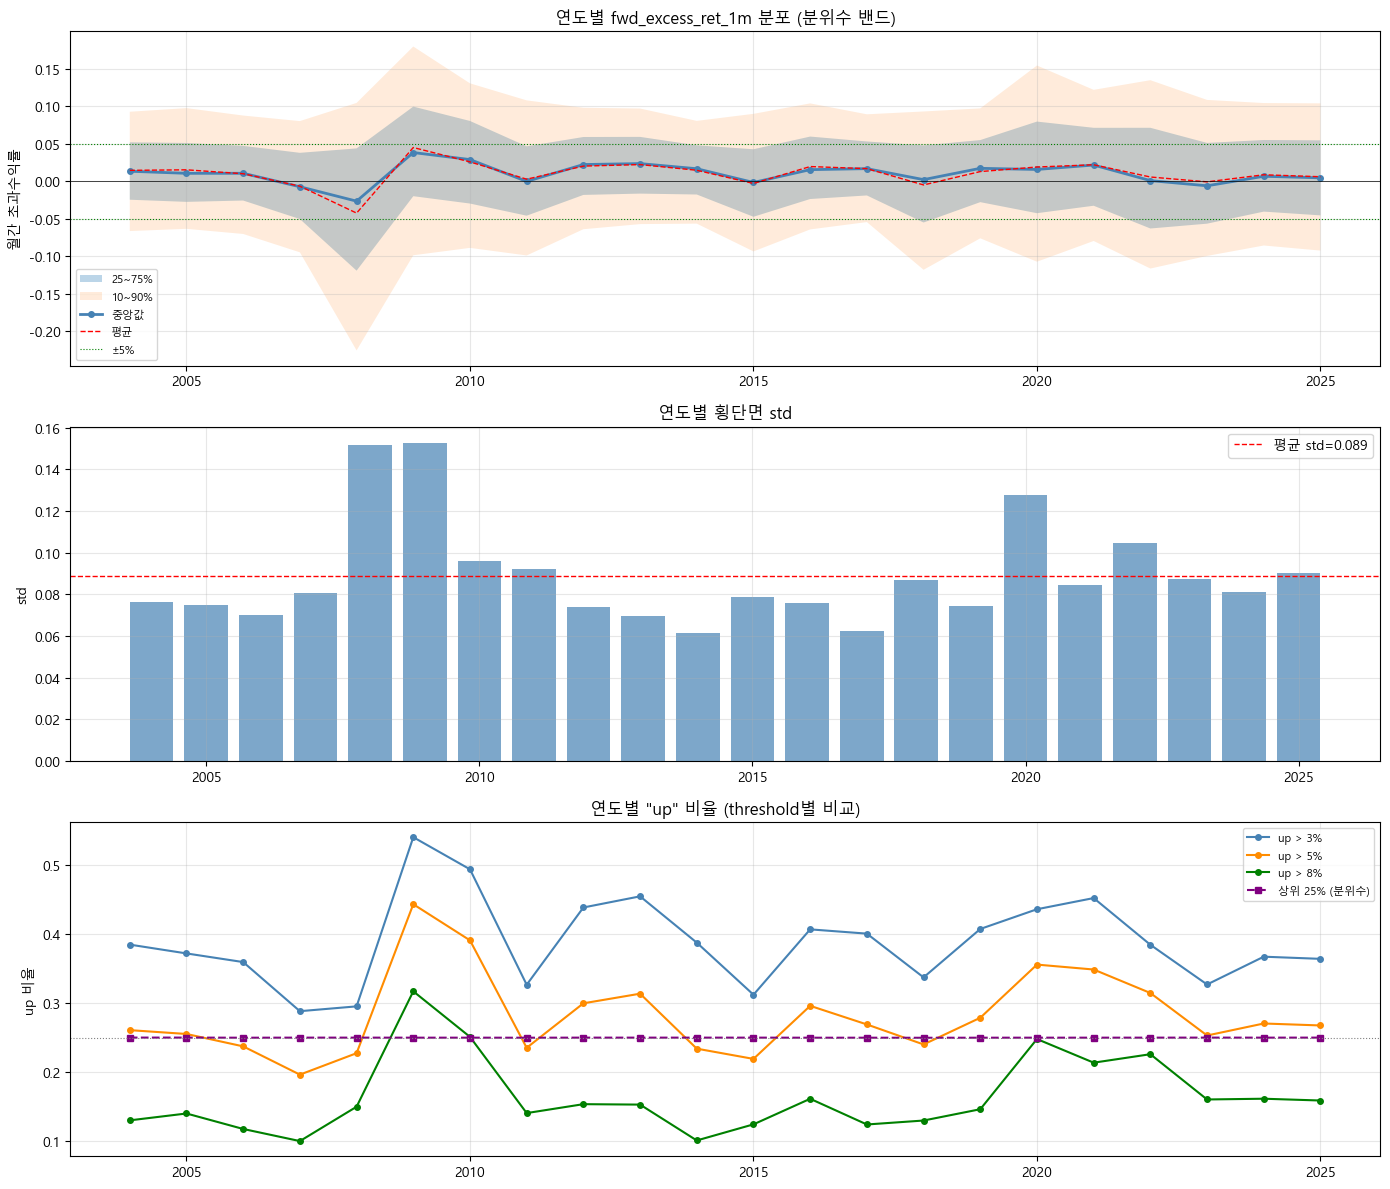


=== threshold별 연도별 up 비율 변동성 (std) ===
작을수록 연도 간 일관성 높음
  고정 3%: std=0.064  (min=28.8% ~ max=54.0%)
  고정 5%: std=0.060  (min=19.6% ~ max=44.3%)
  고정 8%: std=0.054  (min=10.0% ~ max=31.7%)
  분위수 25%: std=0.000  (min=25.0% ~ max=25.0%)


In [9]:
# 연별 분포 분석 — 연도별 cross-sectional 분위수 시계열
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ret = panel['fwd_excess_ret_1m'].copy()
panel_with_year = ret.reset_index()
panel_with_year.columns = ['date', 'fwd_excess_ret_1m']
panel_with_year['year'] = panel_with_year['date'].dt.year

# 연도별 통계
annual_stats = panel_with_year.groupby('year')['fwd_excess_ret_1m'].agg([
    ('mean', 'mean'),
    ('std',  'std'),
    ('p10',  lambda x: x.quantile(0.10)),
    ('p25',  lambda x: x.quantile(0.25)),
    ('p50',  lambda x: x.quantile(0.50)),
    ('p75',  lambda x: x.quantile(0.75)),
    ('p90',  lambda x: x.quantile(0.90)),
    ('pct_up30',   lambda x: (x > x.quantile(0.70)).mean()),  # 상위 30% 비율
    ('pct_down30', lambda x: (x < x.quantile(0.30)).mean()),  # 하위 30% 비율
])

print('=== 연도별 fwd_excess_ret_1m 분포 ===')
print(annual_stats.round(4).to_string())

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. 연도별 중앙값 + 25/75 percentile band
years = annual_stats.index
axes[0].fill_between(years, annual_stats['p25'], annual_stats['p75'], alpha=0.3, label='25~75%')
axes[0].fill_between(years, annual_stats['p10'], annual_stats['p90'], alpha=0.15, label='10~90%')
axes[0].plot(years, annual_stats['p50'], color='steelblue', lw=2, marker='o', ms=4, label='중앙값')
axes[0].plot(years, annual_stats['mean'], color='red', lw=1, ls='--', label='평균')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].axhline( 0.05, color='green', lw=0.8, ls=':', label='±5%')
axes[0].axhline(-0.05, color='green', lw=0.8, ls=':')
axes[0].set_title('연도별 fwd_excess_ret_1m 분포 (분위수 밴드)')
axes[0].set_ylabel('월간 초과수익률')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2. 연도별 std (변동성)
axes[1].bar(years, annual_stats['std'], color='steelblue', alpha=0.7)
axes[1].axhline(annual_stats['std'].mean(), color='red', ls='--', lw=1,
                label=f"평균 std={annual_stats['std'].mean():.3f}")
axes[1].set_title('연도별 횡단면 std')
axes[1].set_ylabel('std')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. 분류 기준 후보 비교 — 각 threshold별 up/down 비율 연도별
thresholds = [0.03, 0.05, 0.08]
colors_t = ['steelblue', 'darkorange', 'green']
for thr, col in zip(thresholds, colors_t):
    pct_up = panel_with_year.groupby('year')['fwd_excess_ret_1m'].apply(lambda x: (x > thr).mean())
    axes[2].plot(years, pct_up, marker='o', ms=4, lw=1.5, color=col, label=f'up > {thr*100:.0f}%')
pct_q25 = panel_with_year.groupby('year')['fwd_excess_ret_1m'].apply(lambda x: (x > x.quantile(0.75)).mean())
axes[2].plot(years, pct_q25, marker='s', ms=4, lw=1.5, color='purple', ls='--', label='상위 25% (분위수)')
axes[2].axhline(0.25, color='gray', lw=0.8, ls=':')
axes[2].set_title('연도별 "up" 비율 (threshold별 비교)')
axes[2].set_ylabel('up 비율')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/05_ml_q/eda_annual_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# 고정 threshold vs 분위수 방식 안정성 비교
print()
print('=== threshold별 연도별 up 비율 변동성 (std) ===')
print('작을수록 연도 간 일관성 높음')
for thr in [0.03, 0.05, 0.08]:
    pct = panel_with_year.groupby('year')['fwd_excess_ret_1m'].apply(lambda x: (x > thr).mean())
    print(f'  고정 {thr*100:.0f}%: std={pct.std():.3f}  (min={pct.min():.1%} ~ max={pct.max():.1%})')
pct_q = panel_with_year.groupby('year')['fwd_excess_ret_1m'].apply(lambda x: (x > x.quantile(0.75)).mean())
print(f'  분위수 25%: std={pct_q.std():.3f}  (min={pct_q.min():.1%} ~ max={pct_q.max():.1%})')
